# Chandu — Step 2

**Calibo AI Academy — Phase 1, Mini Use Case 01**
**Prepared by: Chandu**

In [1]:
# Import the libraries needed for data handling, math, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean grid style and a readable default figure size for every chart.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Show large numbers with thousands separators instead of scientific notation.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the retail sales dataset from the project folder (relative path).
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.head())


  transaction_id        date store_id  ... unit_price   revenue discount_pct
0      TXN000001  2026-01-01      S01  ...   3,075.46  5,843.37            5
1      TXN000002  2026-01-01      S01  ...  11,598.06 11,598.06            0
2      TXN000003  2026-01-01      S01  ...   5,738.37 15,493.60           10
3      TXN000004  2026-01-01      S01  ...   3,281.28  9,351.65            5
4      TXN000005  2026-01-01      S01  ...   1,917.14  1,917.14            0

[5 rows x 10 columns]


In [3]:
# Convert the date column into a true datetime type so later steps can use it.
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


## Step 2 — Category Revenue Trend
**Owner: Chandu**

We look at how monthly revenue for each of the five categories has moved over the six-month window,
to see which categories are growing, declining, or holding steady.


In [4]:
# Extract a "YYYY-MM" month label from each transaction date.
df["month"] = df["date"].dt.to_period("M").astype(str)

# Sum revenue by month and category, then reshape so each category is its own column.
cat_month_revenue = (
    df.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
    .pivot(index="month", columns="category", values="revenue")
)
cat_month_revenue


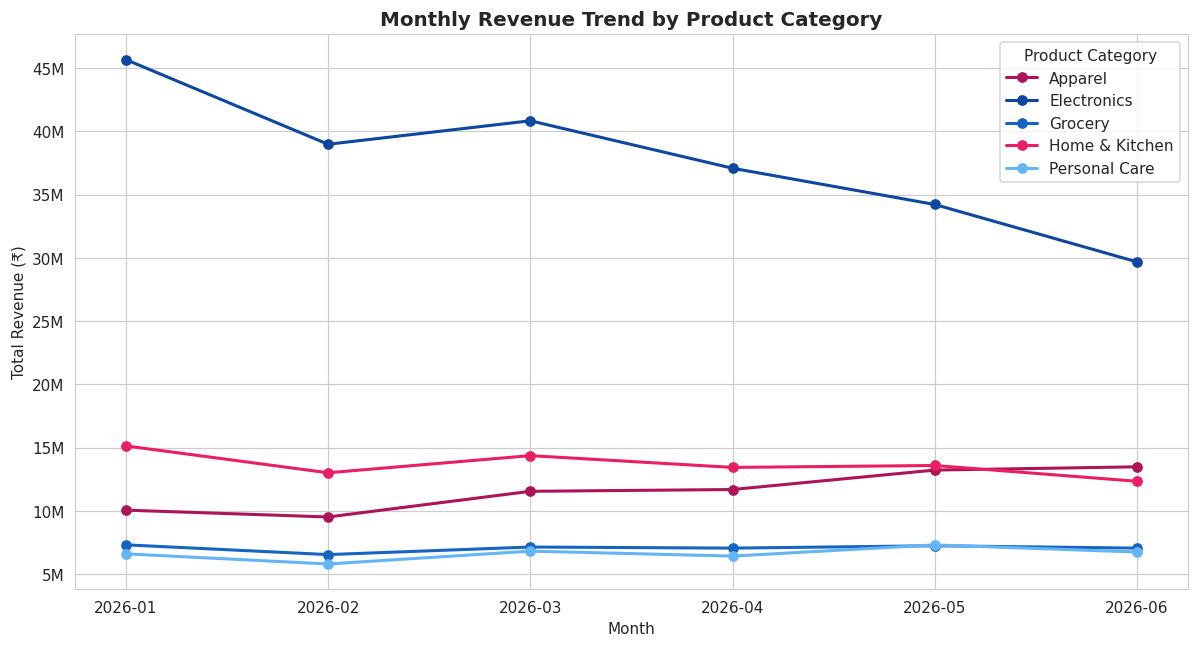

In [5]:
# Line chart of monthly revenue for all five categories (pink + blue only).
CAT_COLORS = {
    "Electronics": "#0d47a1",
    "Apparel": "#ad1457",
    "Grocery": "#1565c0",
    "Home & Kitchen": "#e91e63",
    "Personal Care": "#64b5f6",
}

fig, ax = plt.subplots(figsize=(11, 6))
for category in cat_month_revenue.columns:
    ax.plot(cat_month_revenue.index, cat_month_revenue[category], marker="o", linewidth=2,
            label=category, color=CAT_COLORS.get(category))

ax.set_title("Monthly Revenue Trend by Product Category")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.legend(title="Product Category", loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [6]:
# Compute percent change Jan -> Jun, consistency (coefficient of variation), and total revenue.
first_month = cat_month_revenue.iloc[0]
last_month = cat_month_revenue.iloc[-1]
pct_change = ((last_month - first_month) / first_month * 100).sort_values()

cv = (cat_month_revenue.std() / cat_month_revenue.mean()).sort_values()

total_revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):")
print(pct_change.round(2))
print()
print("Coefficient of variation across the 6 months (lower = more consistent):")
print(cv.round(2))
print()
print("Total 6-month revenue by category (overall scale):")
print(total_revenue_by_category.round(2))
print()
print(f"Declined the most: {pct_change.index[0]} ({pct_change.iloc[0]:.1f}%)")
print(f"Most consistent: {cv.index[0]} (CV = {cv.iloc[0]:.3f})")
print(f"Strongest growth: {pct_change.index[-1]} ({pct_change.iloc[-1]:.1f}%)")


Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):
category
Electronics      -35.02
Home & Kitchen   -18.49
Grocery           -3.55
Personal Care      2.18
Apparel           34.10
dtype: float64

Coefficient of variation across the 6 months (lower = more consistent):
category
Grocery          0.04
Home & Kitchen   0.07
Personal Care    0.08
Apparel          0.14
Electronics      0.15
dtype: float64

Total 6-month revenue by category (overall scale):
category
Electronics      226,527,724.93
Home & Kitchen    81,845,721.33
Apparel           69,479,589.68
Grocery           42,302,580.76
Personal Care     39,648,560.08
Name: revenue, dtype: float64

Declined the most: Electronics (-35.0%)
Most consistent: Grocery (CV = 0.039)
Strongest growth: Apparel (34.1%)


### Business Interpretation
**Electronics fell the most** — its monthly revenue dropped sharply from January to June 2026, and it
is also the least consistent of the five categories month-to-month. This matters a great deal because
Electronics is still by far the *largest* category by total revenue, so a sustained decline of this
size represents a large absolute loss for the business, not a rounding error.

**Apparel is the clear growth story** — it is the only category with sustained month-over-month
growth across the full window, making it the strongest candidate for expanded shelf space and
supplier investment. **Grocery is the most stable** category, moving least from month to month, while
Home & Kitchen and Personal Care sit in between — roughly flat to mildly declining.

For the Category Manager, this points to two clear conversations: challenging Electronics suppliers on
the sharp decline, and backing Apparel suppliers with more confidence given its consistent growth.